# Wyckoff v2 Label Audit

This notebook audits the **v2 structural labeler**:

- **Phases**: `markdown`, `accumulation`, `markup`, `distribution`
- **Ignored bars**: `PHASE_IGNORE_INDEX = -100`
- **Events**: 14 structural Wyckoff events
- **Weights**:
  - `phase_weight` = phase confidence
  - `event_weight` = **positive-event confidence** only

The notebook checks:
1. label integrity
2. phase/event distributions
3. confidence-weight behavior
4. overlap / contradiction rates
5. forward-return directional validity
6. pretrained checkpoint performance


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys, warnings
import torch

warnings.filterwarnings("ignore")
sys.path.insert(0, '/opt/ElegantRL')

PARQUET_PATH = '/opt/ElegantRL/wyckoff_effort/pipeline_output/wyckoff_us30_75pt_bars.parquet'
NPZ_PATH = '/opt/ElegantRL/wyckoff_effort/pipeline_output/wyckoff_us30_75pt.npz'
LABEL_PATH = '/opt/ElegantRL/wyckoff_effort/pipeline_output/structural_labels_us30_75pt.npz'
PRETRAIN_DIR = '/opt/ElegantRL/checkpoints/transformer_us30_75pt'
TRAIN_END_BAR = 13858

FORCE_REBUILD_LABELS = False
PHASE_IGNORE_INDEX = -100

REGIME_NAMES = ['markdown', 'accumulation', 'markup', 'distribution']
EVENT_NAMES = [
    'selling_climax',
    'automatic_rally',
    'st_support',
    'spring',
    'sos',
    'lps',
    'buying_climax',
    'automatic_reaction',
    'st_resistance',
    'upthrust',
    'sow',
    'lpsy',
    'failed_spring',
    'failed_upthrust',
]
EVENT_EXPECTED_SIGN = {
    'selling_climax': +1,
    'automatic_rally': +1,
    'st_support': +1,
    'spring': +1,
    'sos': +1,
    'lps': +1,
    'buying_climax': -1,
    'automatic_reaction': -1,
    'st_resistance': -1,
    'upthrust': -1,
    'sow': -1,
    'lpsy': -1,
    'failed_spring': -1,
    'failed_upthrust': +1,
}

from wyckoff_rl.transformer.config_v2 import N_EVENTS, N_PHASES, EVENT_LABELS, REGIME_LABELS
from wyckoff_rl.transformer.labels_v2 import generate_structural_labels, save_labels

print("=== Runtime config ===")
print("N_PHASES:", N_PHASES)
print("N_EVENTS:", N_EVENTS)
print("EVENT_LABELS:", EVENT_LABELS)
assert N_PHASES == len(REGIME_NAMES), f"Runtime config says N_PHASES={N_PHASES}, notebook expects {len(REGIME_NAMES)}"
assert N_EVENTS == len(EVENT_NAMES), f"Runtime config says N_EVENTS={N_EVENTS}, notebook expects {len(EVENT_NAMES)}"

def inspect_label_file(path: str):
    p = Path(path)
    if not p.exists():
        return {'exists': False, 'path': str(p)}
    data = np.load(p, allow_pickle=True)
    info = {
        'exists': True,
        'path': str(p),
        'files': list(data.files),
        'phase_shape': data['phase'].shape if 'phase' in data.files else None,
        'events_shape': data['events'].shape if 'events' in data.files else None,
        'has_phase_weight': 'phase_weight' in data.files,
        'has_event_weight': 'event_weight' in data.files,
    }
    return info

info = inspect_label_file(LABEL_PATH)
print("\n=== Existing label file info ===")
print(info)

need_rebuild = (
    FORCE_REBUILD_LABELS
    or (not info['exists'])
    or ('events_shape' not in info)
    or (info['events_shape'] is None)
    or (len(info['events_shape']) != 2)
    or (info['events_shape'][1] != len(EVENT_NAMES))
    or (not info.get('has_phase_weight', False))
    or (not info.get('has_event_weight', False))
)

if need_rebuild:
    old_path = Path(LABEL_PATH)
    rebuilt_path = old_path.with_name(old_path.stem + '_v2.npz')
    print("\n=== Regenerating v2 labels ===")
    print("Old/incompatible label file detected.")
    print(f"Writing rebuilt labels to: {rebuilt_path}")
    labels = generate_structural_labels(
        parquet_path=PARQUET_PATH,
        npz_path=NPZ_PATH,
    )
    save_labels(labels, str(rebuilt_path))
    LABEL_PATH = str(rebuilt_path)
else:
    print("\nExisting label file looks v2-compatible.")
    print(f"Using existing LABEL_PATH: {LABEL_PATH}")

bars = pd.read_parquet(PARQUET_PATH)
npz = np.load(NPZ_PATH, allow_pickle=True)
tech_ary = npz['tech_ary']
feature_names = list(npz['feature_names']) if 'feature_names' in npz.files else []

labels_data = np.load(LABEL_PATH, allow_pickle=True)
regime = labels_data['phase'].astype(np.int64)
events = labels_data['events'].astype(np.float32)

phase_weight = (
    labels_data['phase_weight'].astype(np.float32)
    if 'phase_weight' in labels_data.files
    else np.where(regime != PHASE_IGNORE_INDEX, 1.0, 0.0).astype(np.float32)
)

event_conf = (
    labels_data['event_weight'].astype(np.float32)
    if 'event_weight' in labels_data.files
    else events.astype(np.float32)
)
event_conf = np.where(events > 0.5, event_conf, 0.0).astype(np.float32)

VALID_PHASE_MASK = regime != PHASE_IGNORE_INDEX
EVENT_ACTIVE = events > 0.5

assert len(bars) == len(regime) == len(events), "Bars/labels length mismatch"
assert events.ndim == 2, f"Expected 2D event matrix, got shape={events.shape}"
assert events.shape[1] == len(EVENT_NAMES), (
    f"Label file at {LABEL_PATH} is not v2-compatible: "
    f"expected {len(EVENT_NAMES)} events, got {events.shape[1]}"
)

print("\n=== Loaded data ===")
print(f"Bars: {len(bars)}")
print(f"Features: {tech_ary.shape}")
print(f"Using LABEL_PATH: {LABEL_PATH}")
print(f"Train/Val split at bar {TRAIN_END_BAR}")
print(f"Valid phase bars: {VALID_PHASE_MASK.sum()} / {len(regime)}")
print(f"Ignored phase bars: {(~VALID_PHASE_MASK).sum()}")
print(f"Events matrix shape: {events.shape}")
print(f"phase_weight shape: {phase_weight.shape}")
print(f"event_conf shape: {event_conf.shape}")

def find_checkpoint(pretrain_dir: str):
    best_path = Path(pretrain_dir) / 'pretrained_best.pt'
    if best_path.exists():
        return str(best_path)
    ckpts = sorted(glob.glob(str(Path(pretrain_dir) / 'pretrained_*.pt')))
    return ckpts[-1] if ckpts else None

V2_CKPT_PATH = find_checkpoint(PRETRAIN_DIR)
V2_CKPT_COMPATIBLE = False

print("\n=== Checkpoint compatibility ===")
if V2_CKPT_PATH is None:
    print("No checkpoint found.")
else:
    print("Found checkpoint:", V2_CKPT_PATH)
    try:
        ckpt_meta = torch.load(V2_CKPT_PATH, map_location='cpu', weights_only=False)
    except TypeError:
        ckpt_meta = torch.load(V2_CKPT_PATH, map_location='cpu')
    cfg = ckpt_meta.get('config', None)
    if cfg is None:
        print("Checkpoint has no config object; cannot verify compatibility.")
    else:
        ckpt_n_phases = getattr(cfg, 'n_phases', None)
        ckpt_n_events = getattr(cfg, 'n_events', None)
        print("checkpoint n_phases:", ckpt_n_phases)
        print("checkpoint n_events:", ckpt_n_events)
        V2_CKPT_COMPATIBLE = (
            ckpt_n_phases == len(REGIME_NAMES)
            and ckpt_n_events == len(EVENT_NAMES)
        )
        if V2_CKPT_COMPATIBLE:
            print("Checkpoint is v2-compatible.")
        else:
            print("Checkpoint is NOT v2-compatible. Retrain before running model-eval cells.")


=== Runtime config ===
N_PHASES: 4
N_EVENTS: 14
EVENT_LABELS: {0: 'selling_climax', 1: 'automatic_rally', 2: 'st_support', 3: 'spring', 4: 'sos', 5: 'lps', 6: 'buying_climax', 7: 'automatic_reaction', 8: 'st_resistance', 9: 'upthrust', 10: 'sow', 11: 'lpsy', 12: 'failed_spring', 13: 'failed_upthrust'}

=== Existing label file info ===
{'exists': True, 'path': '/opt/ElegantRL/wyckoff_effort/pipeline_output/structural_labels_us30_75pt.npz', 'files': ['phase', 'events'], 'phase_shape': (17323,), 'events_shape': (17323, 4), 'has_phase_weight': False, 'has_event_weight': False}

=== Regenerating v2 labels ===
Old/incompatible label file detected.
Writing rebuilt labels to: /opt/ElegantRL/wyckoff_effort/pipeline_output/structural_labels_us30_75pt_v2.npz

=== Loaded data ===
Bars: 17323
Features: (17323, 72)
Using LABEL_PATH: /opt/ElegantRL/wyckoff_effort/pipeline_output/structural_labels_us30_75pt_v2.npz
Train/Val split at bar 13858
Valid phase bars: 10401 / 17323
Ignored phase bars: 6922
Ev

=== Weight integrity checks ===
Ignored phase bars with nonzero phase_weight: 0
Valid phase bars with zero/negative phase_weight: 0
Negative event slots with nonzero event_conf: 0
Positive event slots with zero/negative event_conf: 0

=== Phase weight stats by class ===
  markdown        : n=  2312  mean=0.816  median=0.750  p10=0.750  p90=0.875
  accumulation    : n=  2861  mean=0.815  median=0.830  p10=0.760  p90=0.900
  markup          : n=  2237  mean=0.803  median=0.750  p10=0.750  p90=0.875
  distribution    : n=  2991  mean=0.806  median=0.760  p10=0.760  p90=0.900

=== Event confidence stats (positive labels only) ===
  selling_climax      : n=  236  mean=0.713  median=0.714  p10=0.644  p90=0.779
  automatic_rally     : n=  236  mean=0.741  median=0.719  p10=0.527  p90=1.000
  st_support          : n=   87  mean=0.690  median=0.677  p10=0.577  p90=0.821
  spring              : n=   30  mean=0.712  median=0.712  p10=0.618  p90=0.800
  sos                 : n=   12  mean=0.876  m

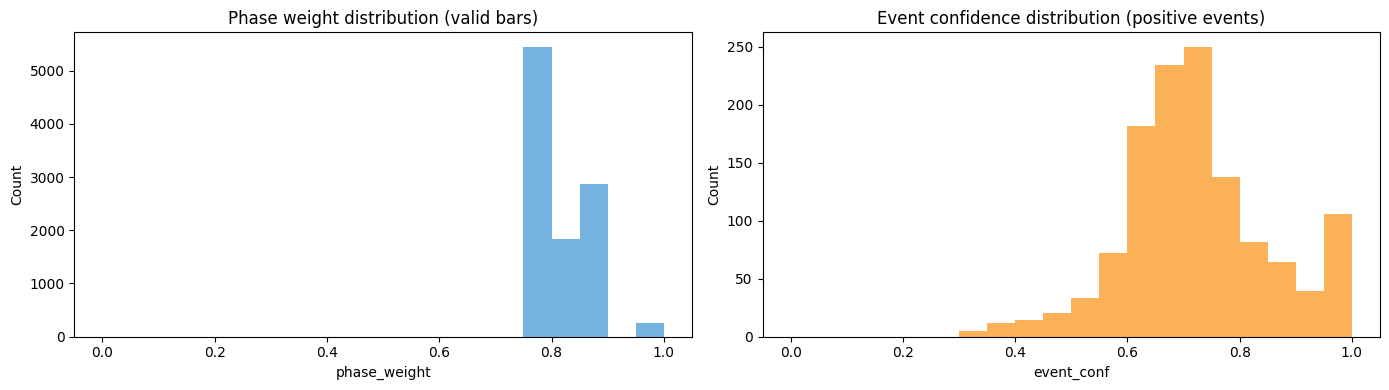

In [2]:
print("=== Weight integrity checks ===")
ignored_nonzero_phase = ((~VALID_PHASE_MASK) & (phase_weight > 0)).sum()
valid_zero_phase = (VALID_PHASE_MASK & (phase_weight <= 0)).sum()
negative_event_nonzero_conf = ((~EVENT_ACTIVE) & (event_conf > 0)).sum()
positive_event_zero_conf = (EVENT_ACTIVE & (event_conf <= 0)).sum()

print(f"Ignored phase bars with nonzero phase_weight: {ignored_nonzero_phase}")
print(f"Valid phase bars with zero/negative phase_weight: {valid_zero_phase}")
print(f"Negative event slots with nonzero event_conf: {negative_event_nonzero_conf}")
print(f"Positive event slots with zero/negative event_conf: {positive_event_zero_conf}")

print("\n=== Phase weight stats by class ===")
for i, name in enumerate(REGIME_NAMES):
    mask = regime == i
    if mask.sum() == 0:
        print(f"  {name:16s}: no samples")
        continue
    vals = phase_weight[mask]
    print(
        f"  {name:16s}: n={mask.sum():6d}  "
        f"mean={vals.mean():.3f}  median={np.median(vals):.3f}  "
        f"p10={np.percentile(vals, 10):.3f}  p90={np.percentile(vals, 90):.3f}"
    )

print("\n=== Event confidence stats (positive labels only) ===")
for j, name in enumerate(EVENT_NAMES):
    mask = EVENT_ACTIVE[:, j]
    if mask.sum() == 0:
        print(f"  {name:20s}: no positives")
        continue
    vals = event_conf[mask, j]
    print(
        f"  {name:20s}: n={mask.sum():5d}  "
        f"mean={vals.mean():.3f}  median={np.median(vals):.3f}  "
        f"p10={np.percentile(vals, 10):.3f}  p90={np.percentile(vals, 90):.3f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

if VALID_PHASE_MASK.sum() > 0:
    axes[0].hist(phase_weight[VALID_PHASE_MASK], bins=np.linspace(0, 1, 21), color="#5DA5DA", alpha=0.85)
axes[0].set_title("Phase weight distribution (valid bars)")
axes[0].set_xlabel("phase_weight")
axes[0].set_ylabel("Count")

all_pos_conf = event_conf[EVENT_ACTIVE]
if all_pos_conf.size > 0:
    axes[1].hist(all_pos_conf, bins=np.linspace(0, 1, 21), color="#FAA43A", alpha=0.85)
axes[1].set_title("Event confidence distribution (positive events)")
axes[1].set_xlabel("event_conf")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


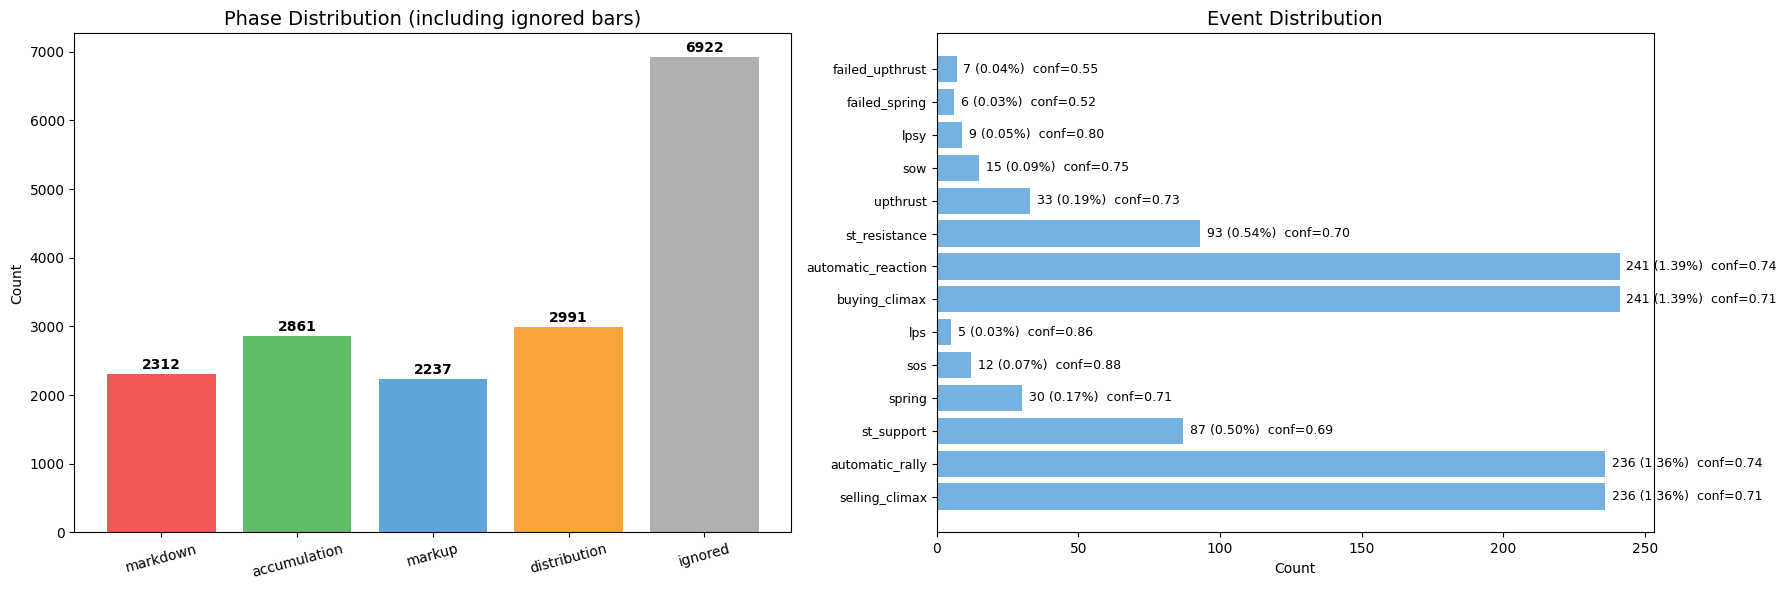


=== Phase distribution (valid only) ===
  markdown        :   2312 ( 22.2%)
  accumulation    :   2861 ( 27.5%)
  markup          :   2237 ( 21.5%)
  distribution    :   2991 ( 28.8%)
  ignored         :   6922 ( 40.0%)

=== Events ===
  selling_climax      :   236 ( 1.36%)  mean_conf=0.71
  automatic_rally     :   236 ( 1.36%)  mean_conf=0.74
  st_support          :    87 ( 0.50%)  mean_conf=0.69
  spring              :    30 ( 0.17%)  mean_conf=0.71
  sos                 :    12 ( 0.07%)  mean_conf=0.88
  lps                 :     5 ( 0.03%)  mean_conf=0.86
  buying_climax       :   241 ( 1.39%)  mean_conf=0.71
  automatic_reaction  :   241 ( 1.39%)  mean_conf=0.74
  st_resistance       :    93 ( 0.54%)  mean_conf=0.70
  upthrust            :    33 ( 0.19%)  mean_conf=0.73
  sow                 :    15 ( 0.09%)  mean_conf=0.75
  lpsy                :     9 ( 0.05%)  mean_conf=0.80
  failed_spring       :     6 ( 0.03%)  mean_conf=0.52
  failed_upthrust     :     7 ( 0.04%)  mean_con

In [3]:
phase_counts = np.bincount(regime[VALID_PHASE_MASK], minlength=len(REGIME_NAMES))
phase_pcts = phase_counts / max(VALID_PHASE_MASK.sum(), 1) * 100
ignored_count = (~VALID_PHASE_MASK).sum()

event_counts = EVENT_ACTIVE.sum(axis=0)
event_pcts = event_counts / len(events) * 100
event_mean_conf = np.array([
    event_conf[EVENT_ACTIVE[:, j], j].mean() if EVENT_ACTIVE[:, j].sum() > 0 else 0.0
    for j in range(len(EVENT_NAMES))
])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

phase_labels_plot = REGIME_NAMES + ["ignored"]
phase_counts_plot = list(phase_counts) + [ignored_count]
phase_colors = ["#F15854", "#60BD68", "#5DA5DA", "#FAA43A", "#B0B0B0"]

bars_p = axes[0].bar(phase_labels_plot, phase_counts_plot, color=phase_colors)
for b, c in zip(bars_p, phase_counts_plot):
    axes[0].text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + max(phase_counts_plot) * 0.01,
        f"{c}",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )
axes[0].set_title("Phase Distribution (including ignored bars)", fontsize=14)
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=15)

y = np.arange(len(EVENT_NAMES))
axes[1].barh(y, event_counts, color="#5DA5DA", alpha=0.85)
offset = max(event_counts.max() * 0.01, 1) if len(event_counts) else 1
for i, (cnt, pct, conf) in enumerate(zip(event_counts, event_pcts, event_mean_conf)):
    axes[1].text(
        cnt + offset,
        i,
        f"{cnt} ({pct:.2f}%)  conf={conf:.2f}",
        va="center",
        fontsize=9,
    )
axes[1].set_yticks(y)
axes[1].set_yticklabels(EVENT_NAMES, fontsize=9)
axes[1].set_title("Event Distribution", fontsize=14)
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

print("\n=== Phase distribution (valid only) ===")
for i, name in enumerate(REGIME_NAMES):
    print(f"  {name:16s}: {phase_counts[i]:6d} ({phase_pcts[i]:5.1f}%)")
print(f"  {'ignored':16s}: {ignored_count:6d} ({ignored_count / len(regime) * 100:5.1f}%)")

print("\n=== Events ===")
for j, name in enumerate(EVENT_NAMES):
    print(f"  {name:20s}: {event_counts[j]:5d} ({event_pcts[j]:5.2f}%)  mean_conf={event_mean_conf[j]:.2f}")

print("\n=== Rare-event warning ===")
for j, name in enumerate(EVENT_NAMES):
    pct = event_pcts[j]
    if pct < 0.2:
        status = "VERY SPARSE"
    elif pct < 0.75:
        status = "SPARSE"
    elif pct > 8.0:
        status = "SUSPICIOUSLY FREQUENT"
    else:
        status = "OK"
    print(f"  {name:20s}: {pct:5.2f}%  -> {status}")


In [4]:
train_mask = np.arange(len(regime)) < TRAIN_END_BAR if TRAIN_END_BAR > 0 else np.ones(len(regime), dtype=bool)
val_mask = ~train_mask if TRAIN_END_BAR > 0 else np.zeros(len(regime), dtype=bool)

train_valid = train_mask & VALID_PHASE_MASK
val_valid = val_mask & VALID_PHASE_MASK

print("=== Phase by split (valid only) ===")
for i, name in enumerate(REGIME_NAMES):
    tr = ((regime == i) & train_valid).sum()
    va = ((regime == i) & val_valid).sum()
    tr_pct = tr / max(train_valid.sum(), 1) * 100
    va_pct = va / max(val_valid.sum(), 1) * 100
    print(f"  {name:16s}: train={tr:5d} ({tr_pct:5.1f}%)   val={va:5d} ({va_pct:5.1f}%)")

print("\nIgnored phase bars:")
print(f"  train={(train_mask & ~VALID_PHASE_MASK).sum():5d}")
print(f"  val  ={(val_mask & ~VALID_PHASE_MASK).sum():5d}")

print("\n=== Events by split ===")
for j, name in enumerate(EVENT_NAMES):
    tr = EVENT_ACTIVE[train_mask, j].sum()
    va = EVENT_ACTIVE[val_mask, j].sum()
    tr_pct = tr / max(train_mask.sum(), 1) * 100
    va_pct = va / max(val_mask.sum(), 1) * 100 if val_mask.sum() > 0 else 0.0
    print(f"  {name:20s}: train={tr:5d} ({tr_pct:5.2f}%)   val={va:5d} ({va_pct:5.2f}%)")


=== Phase by split (valid only) ===
  markdown        : train= 1589 ( 19.4%)   val=  723 ( 33.0%)
  accumulation    : train= 2193 ( 26.7%)   val=  668 ( 30.5%)
  markup          : train= 2025 ( 24.7%)   val=  212 (  9.7%)
  distribution    : train= 2403 ( 29.3%)   val=  588 ( 26.8%)

Ignored phase bars:
  train= 5648
  val  = 1274

=== Events by split ===
  selling_climax      : train=  185 ( 1.33%)   val=   51 ( 1.47%)
  automatic_rally     : train=  184 ( 1.33%)   val=   52 ( 1.50%)
  st_support          : train=   65 ( 0.47%)   val=   22 ( 0.63%)
  spring              : train=   19 ( 0.14%)   val=   11 ( 0.32%)
  sos                 : train=    6 ( 0.04%)   val=    6 ( 0.17%)
  lps                 : train=    1 ( 0.01%)   val=    4 ( 0.12%)
  buying_climax       : train=  191 ( 1.38%)   val=   50 ( 1.44%)
  automatic_reaction  : train=  191 ( 1.38%)   val=   50 ( 1.44%)
  st_resistance       : train=   69 ( 0.50%)   val=   24 ( 0.69%)
  upthrust            : train=   25 ( 0.18%)   v

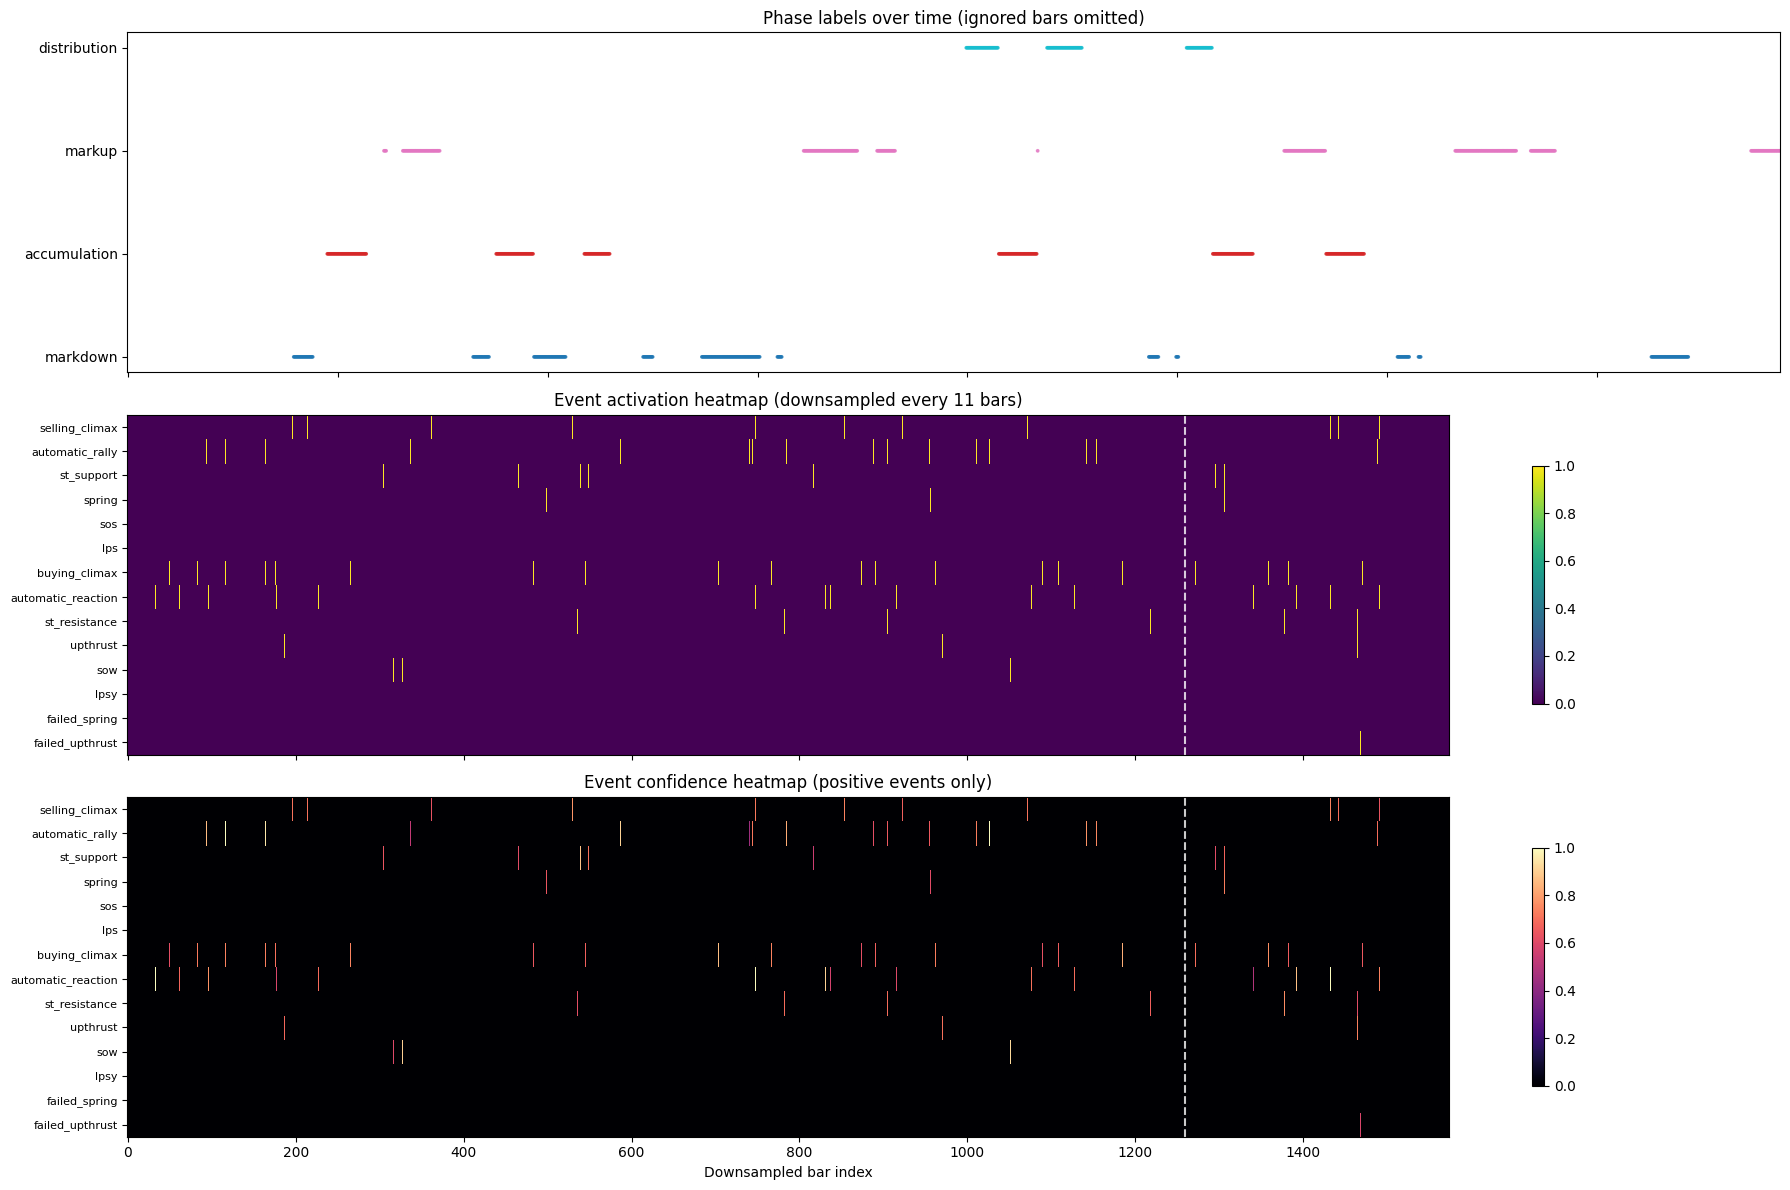

=== Inter-event gap stats ===
  selling_climax      : median_gap=   64   mean_gap=  73.4   pct_gap<=1=  0.0%
  automatic_rally     : median_gap=   64   mean_gap=  73.4   pct_gap<=1=  0.0%
  st_support          : median_gap=  136   mean_gap= 195.2   pct_gap<=1=  0.0%
  spring              : median_gap=  396   mean_gap= 573.5   pct_gap<=1=  0.0%
  sos                 : median_gap=  661   mean_gap=1471.4   pct_gap<=1=  0.0%
  lps                 : median_gap=  682   mean_gap=1420.0   pct_gap<=1=  0.0%
  buying_climax       : median_gap=   62   mean_gap=  71.3   pct_gap<=1=  0.0%
  automatic_reaction  : median_gap=   64   mean_gap=  71.2   pct_gap<=1=  0.0%
  st_resistance       : median_gap=   55   mean_gap= 184.7   pct_gap<=1=  0.0%
  upthrust            : median_gap=  388   mean_gap= 472.8   pct_gap<=1=  0.0%
  sow                 : median_gap=  720   mean_gap=1071.6   pct_gap<=1=  0.0%
  lpsy                : median_gap= 1022   mean_gap=1874.8   pct_gap<=1=  0.0%
  failed_spring       

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

phase_series = np.full(len(regime), np.nan)
phase_series[VALID_PHASE_MASK] = regime[VALID_PHASE_MASK]

axes[0].scatter(
    np.arange(len(regime))[VALID_PHASE_MASK],
    phase_series[VALID_PHASE_MASK],
    c=phase_series[VALID_PHASE_MASK],
    cmap="tab10",
    s=3,
    alpha=0.8,
)
if TRAIN_END_BAR > 0:
    axes[0].axvline(TRAIN_END_BAR, color="black", ls="--", alpha=0.6)
axes[0].set_yticks(range(len(REGIME_NAMES)))
axes[0].set_yticklabels(REGIME_NAMES)
axes[0].set_title("Phase labels over time (ignored bars omitted)")

step = max(1, len(events) // 1500)
event_active_ds = EVENT_ACTIVE[::step].T.astype(float)
im1 = axes[1].imshow(event_active_ds, aspect="auto", interpolation="nearest", cmap="viridis")
axes[1].set_yticks(range(len(EVENT_NAMES)))
axes[1].set_yticklabels(EVENT_NAMES, fontsize=8)
axes[1].set_title(f"Event activation heatmap (downsampled every {step} bars)")
if TRAIN_END_BAR > 0:
    axes[1].axvline(TRAIN_END_BAR // step, color="white", ls="--", alpha=0.8)
plt.colorbar(im1, ax=axes[1], shrink=0.7)

conf_ds = event_conf[::step].T * event_active_ds
im2 = axes[2].imshow(conf_ds, aspect="auto", interpolation="nearest", cmap="magma", vmin=0, vmax=1)
axes[2].set_yticks(range(len(EVENT_NAMES)))
axes[2].set_yticklabels(EVENT_NAMES, fontsize=8)
axes[2].set_title("Event confidence heatmap (positive events only)")
if TRAIN_END_BAR > 0:
    axes[2].axvline(TRAIN_END_BAR // step, color="white", ls="--", alpha=0.8)
axes[2].set_xlabel("Downsampled bar index")
plt.colorbar(im2, ax=axes[2], shrink=0.7)

plt.tight_layout()
plt.show()

print("=== Inter-event gap stats ===")
for j, name in enumerate(EVENT_NAMES):
    active = np.where(EVENT_ACTIVE[:, j])[0]
    if len(active) < 2:
        print(f"  {name:20s}: too few events")
        continue
    gaps = np.diff(active)
    print(
        f"  {name:20s}: median_gap={np.median(gaps):5.0f}   "
        f"mean_gap={np.mean(gaps):6.1f}   pct_gap<=1={(gaps <= 1).mean() * 100:5.1f}%"
    )


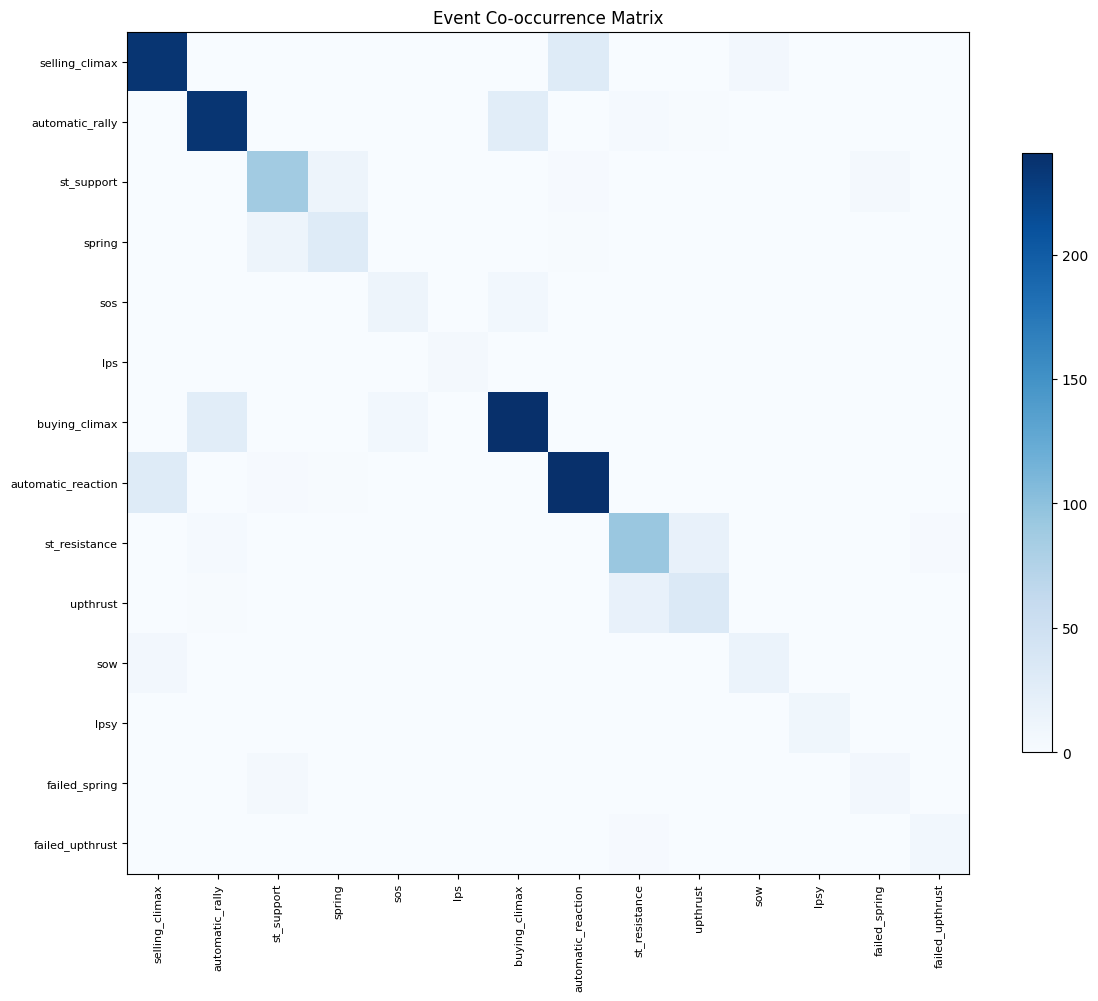

=== Contradictory overlaps ===
  spring               & upthrust            :     0 bars
  sos                  & sow                 :     0 bars
  lps                  & lpsy                :     0 bars
  failed_spring        & failed_upthrust     :     0 bars
  selling_climax       & buying_climax       :     0 bars
  automatic_rally      & automatic_reaction  :     0 bars
  st_support           & st_resistance       :     0 bars

Bars with any bullish-family AND bearish-family event: 82

=== Events-per-bar distribution ===
   0 events:  16184 bars (93.42%)
   1 events:   1027 bars ( 5.93%)
   2 events:    112 bars ( 0.65%)


In [6]:
cooc = np.zeros((len(EVENT_NAMES), len(EVENT_NAMES)), dtype=int)
for i in range(len(EVENT_NAMES)):
    for j in range(len(EVENT_NAMES)):
        cooc[i, j] = np.logical_and(EVENT_ACTIVE[:, i], EVENT_ACTIVE[:, j]).sum()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cooc, cmap="Blues")
ax.set_xticks(range(len(EVENT_NAMES)))
ax.set_xticklabels(EVENT_NAMES, rotation=90, fontsize=8)
ax.set_yticks(range(len(EVENT_NAMES)))
ax.set_yticklabels(EVENT_NAMES, fontsize=8)
ax.set_title("Event Co-occurrence Matrix")
plt.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()

contradiction_pairs = [
    ("spring", "upthrust"),
    ("sos", "sow"),
    ("lps", "lpsy"),
    ("failed_spring", "failed_upthrust"),
    ("selling_climax", "buying_climax"),
    ("automatic_rally", "automatic_reaction"),
    ("st_support", "st_resistance"),
]

print("=== Contradictory overlaps ===")
for a, b in contradiction_pairs:
    ia = EVENT_NAMES.index(a)
    ib = EVENT_NAMES.index(b)
    both = np.logical_and(EVENT_ACTIVE[:, ia], EVENT_ACTIVE[:, ib]).sum()
    print(f"  {a:20s} & {b:20s}: {both:5d} bars")

bullish_family = [
    "selling_climax",
    "automatic_rally",
    "st_support",
    "spring",
    "sos",
    "lps",
    "failed_upthrust",
]
bearish_family = [
    "buying_climax",
    "automatic_reaction",
    "st_resistance",
    "upthrust",
    "sow",
    "lpsy",
    "failed_spring",
]

bull_mask = np.zeros(len(events), dtype=bool)
bear_mask = np.zeros(len(events), dtype=bool)

for name in bullish_family:
    bull_mask |= EVENT_ACTIVE[:, EVENT_NAMES.index(name)]
for name in bearish_family:
    bear_mask |= EVENT_ACTIVE[:, EVENT_NAMES.index(name)]

both_sides = np.logical_and(bull_mask, bear_mask).sum()
print(f"\nBars with any bullish-family AND bearish-family event: {both_sides}")

print("\n=== Events-per-bar distribution ===")
n_active_per_bar = EVENT_ACTIVE.sum(axis=1)
for k in range(int(n_active_per_bar.max()) + 1):
    cnt = (n_active_per_bar == k).sum()
    print(f"  {k:2d} events: {cnt:6d} bars ({cnt / len(events) * 100:5.2f}%)")


In [8]:
def plot_event_examples(event_name, n_examples=8, context=40, min_conf=0.75):
    idx = EVENT_NAMES.index(event_name)
    active = np.where(EVENT_ACTIVE[:, idx] & (event_conf[:, idx] >= min_conf))[0]
    if len(active) < n_examples:
        active = np.where(EVENT_ACTIVE[:, idx])[0]
    if len(active) == 0:
        print(f"No examples found for {event_name}")
        return

    step = max(1, len(active) // n_examples)
    sample_idx = active[::step][:n_examples]

    n_cols = min(4, len(sample_idx))
    n_rows = (len(sample_idx) + n_cols - 1) // n_cols

    fig, axes_grid = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
    axes = np.array(axes_grid).reshape(-1)

    for ax_i, bar_i in enumerate(sample_idx):
        ax = axes[ax_i]
        start = max(0, bar_i - context)
        end = min(len(bars), bar_i + context // 2)
        window = bars.iloc[start:end]
        x = np.arange(len(window))

        for xi, (_, row) in enumerate(window.iterrows()):
            color = "#60BD68" if row["close"] >= row["open"] else "#F15854"
            ax.plot([xi, xi], [row["low"], row["high"]], color="gray", lw=0.6, alpha=0.9)
            ax.plot([xi, xi], [row["open"], row["close"]], color=color, lw=2.3)

        event_x = bar_i - start
        ax.axvline(event_x, color="blue", ls="--", lw=1.5, alpha=0.9)
        ax.set_title(f"{event_name} @ {bar_i}\\nconf={event_conf[bar_i, idx]:.2f}", fontsize=10)

        ax2 = ax.twinx()
        vol_window = window["volume"].values
        ax2.bar(x, vol_window, alpha=0.14, color="gray", width=0.8)
        ax2.set_ylim(0, max(vol_window.max() * 3, 1))
        ax2.set_yticks([])

        if "delta" in window.columns:
            ax3 = ax.twinx()
            delta_vals = window["delta"].values
            ax3.spines["right"].set_position(("axes", 1.08))
            colors = np.where(delta_vals >= 0, "#60BD68", "#F15854")
            ax3.bar(x, delta_vals, alpha=0.15, color=colors, width=0.35)
            ax3.set_yticks([])

        ax.set_xlim(-1, len(window))

    for ax_i in range(len(sample_idx), len(axes)):
        axes[ax_i].set_visible(False)

    plt.suptitle(f"{event_name.upper()} examples", fontsize=14)
    plt.tight_layout()
    plt.show()

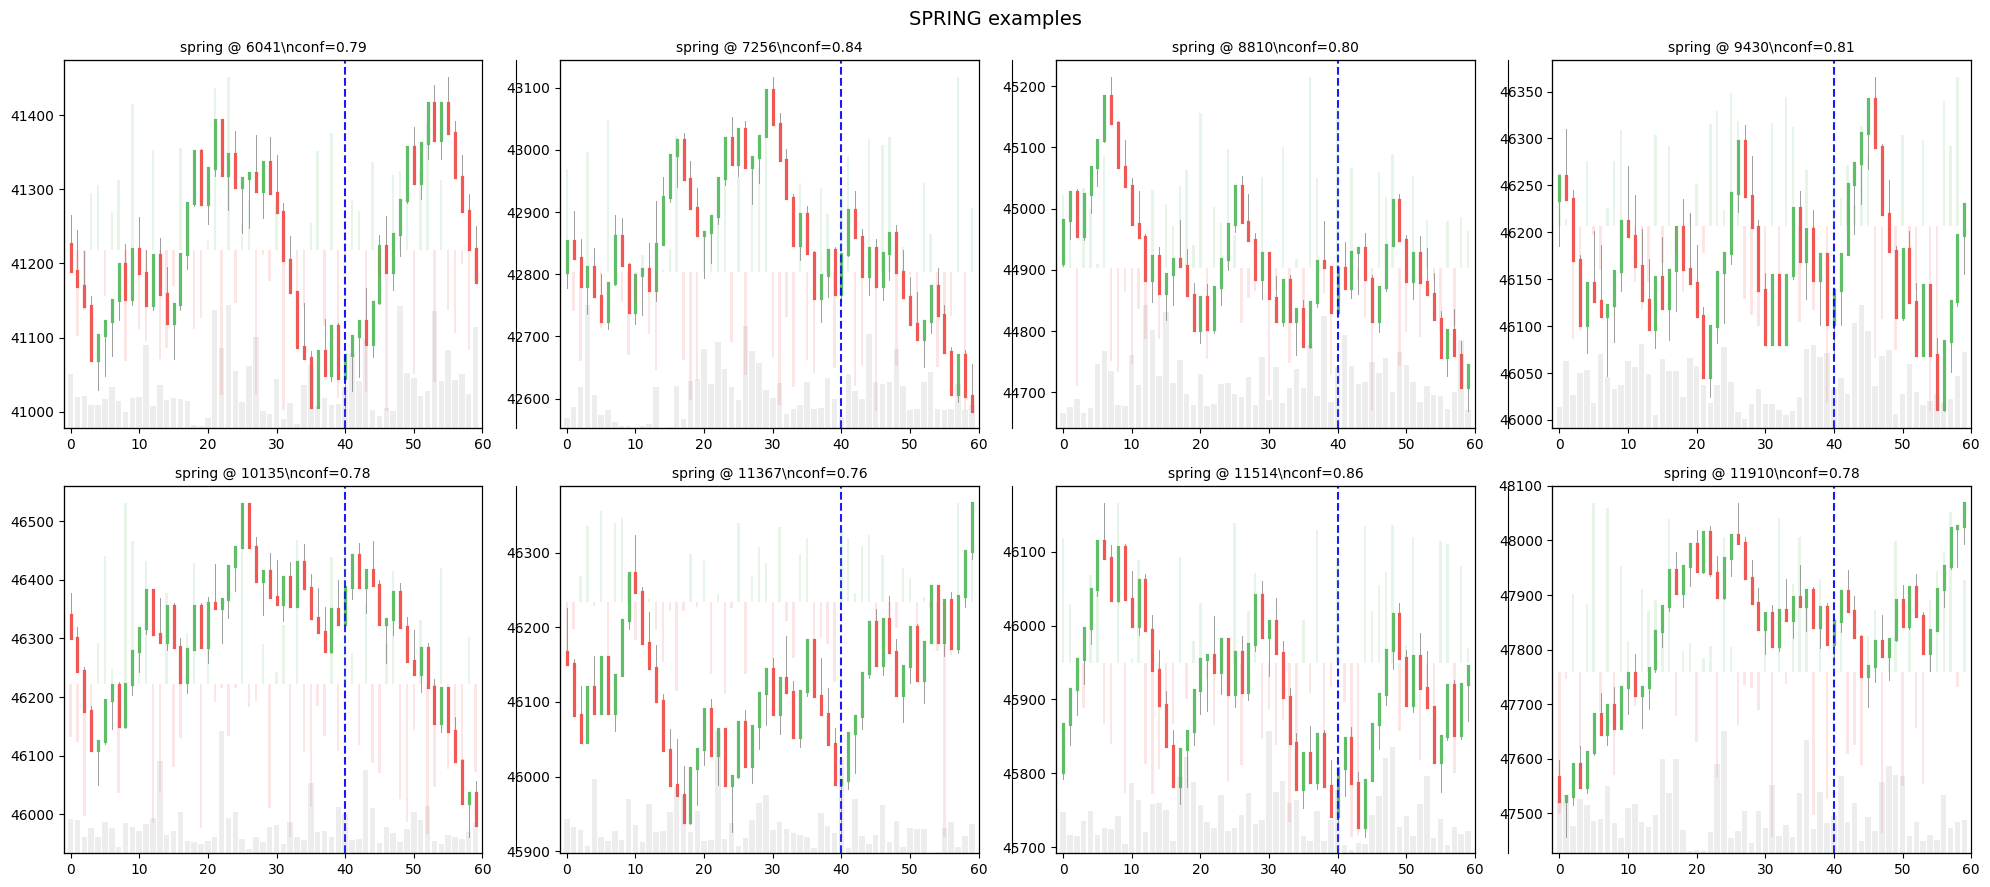

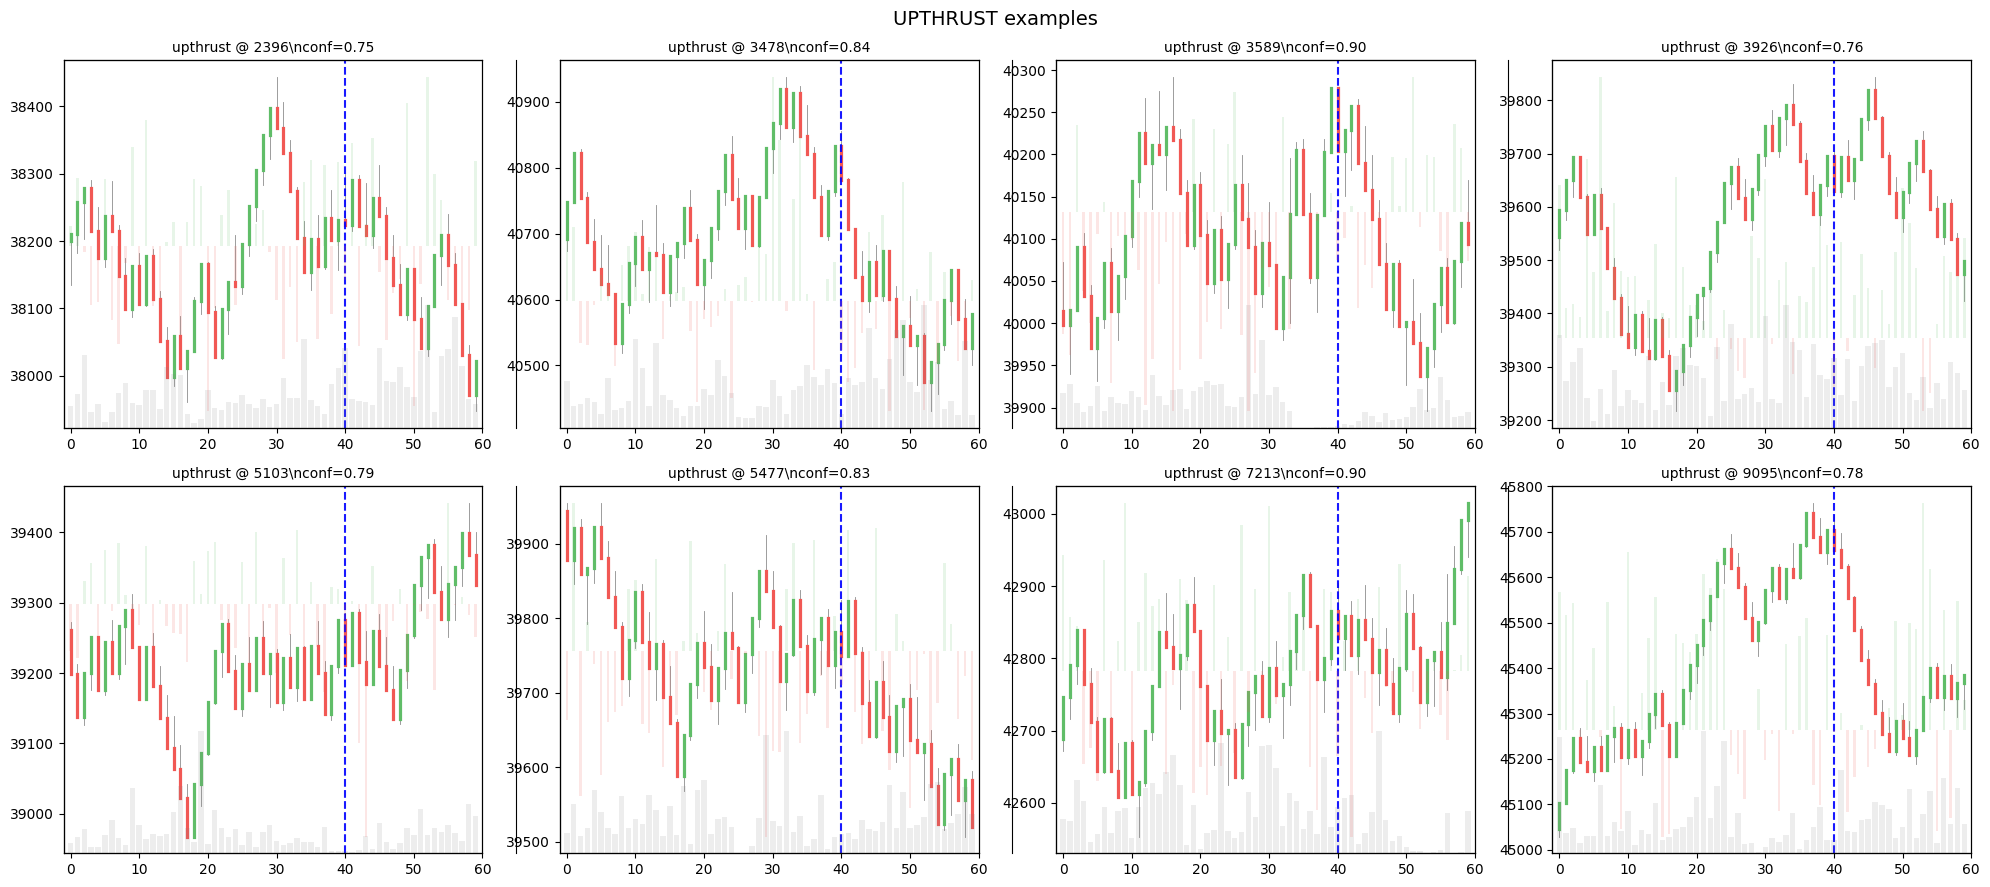

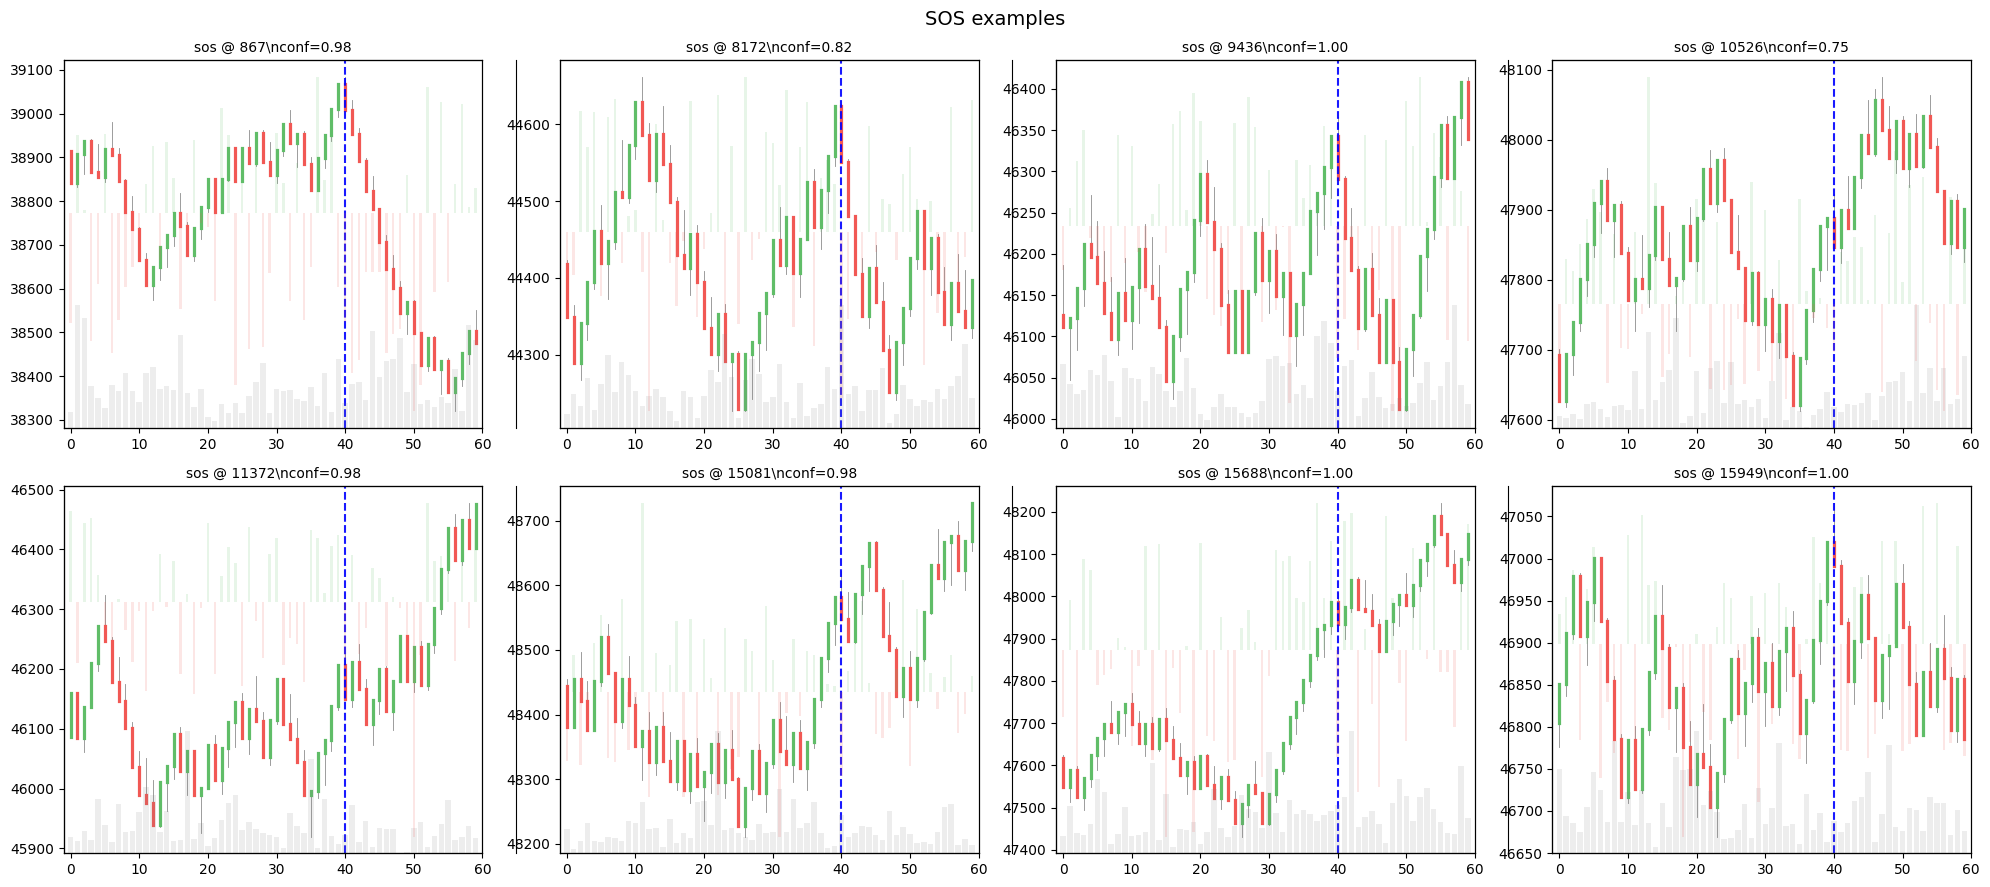

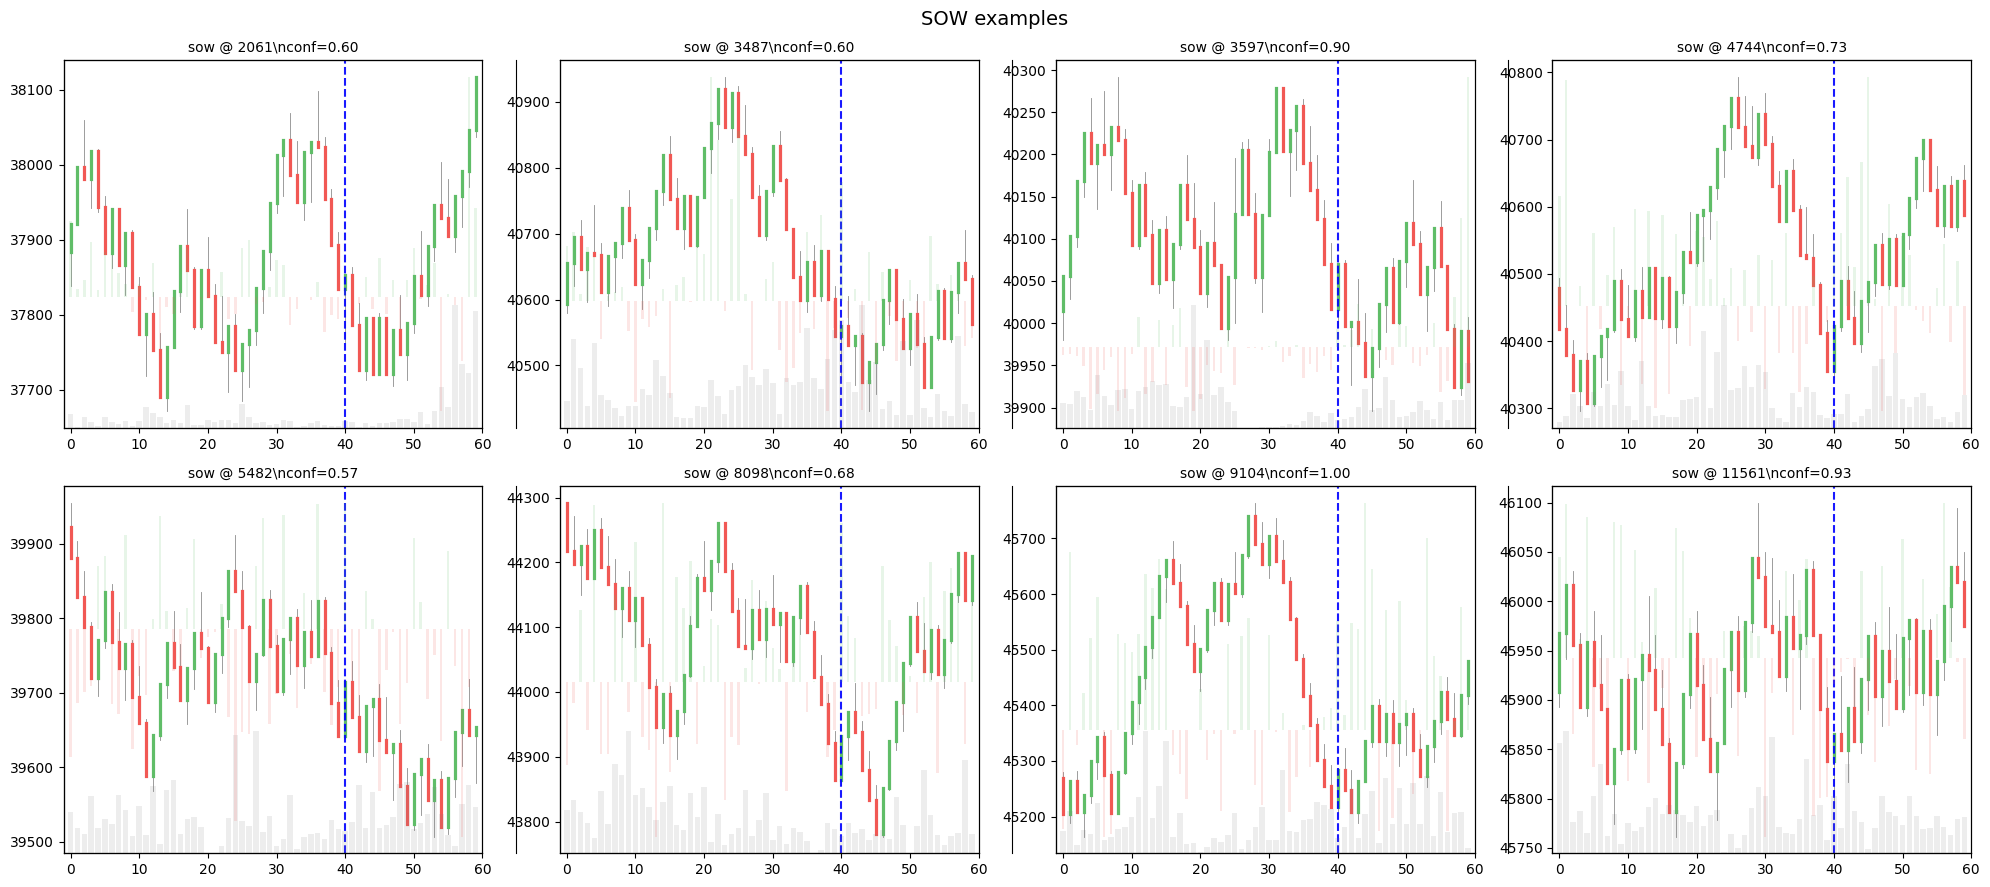

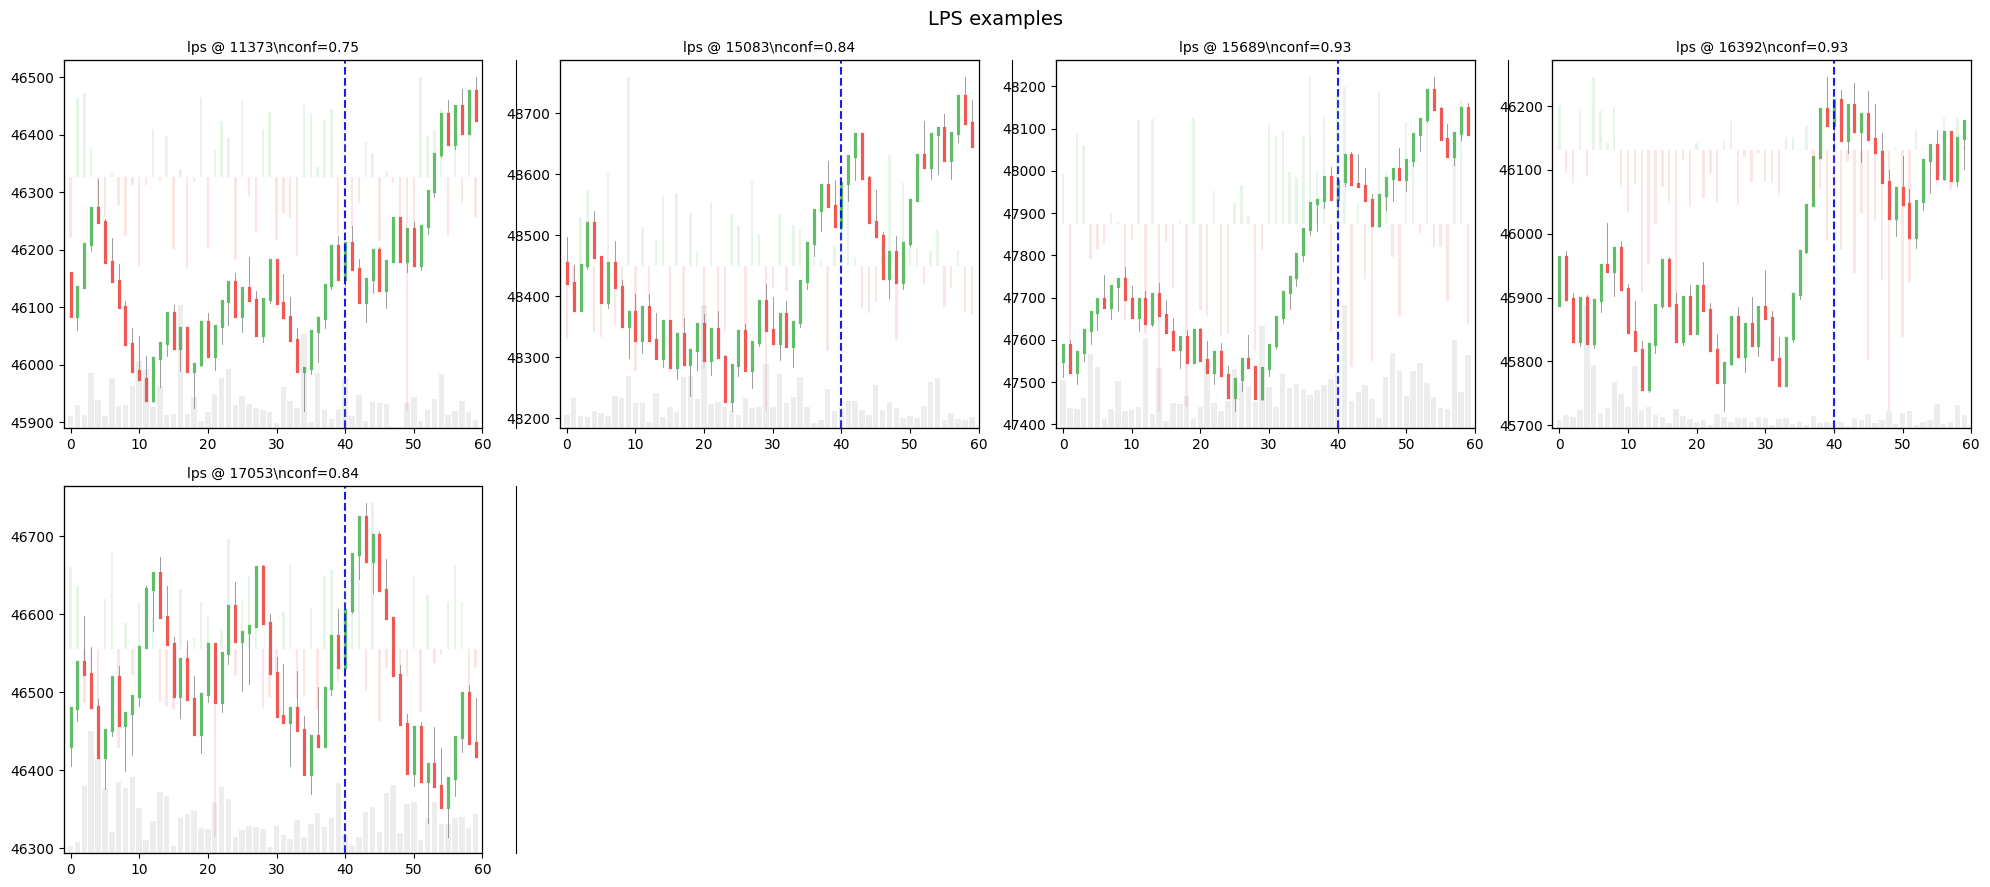

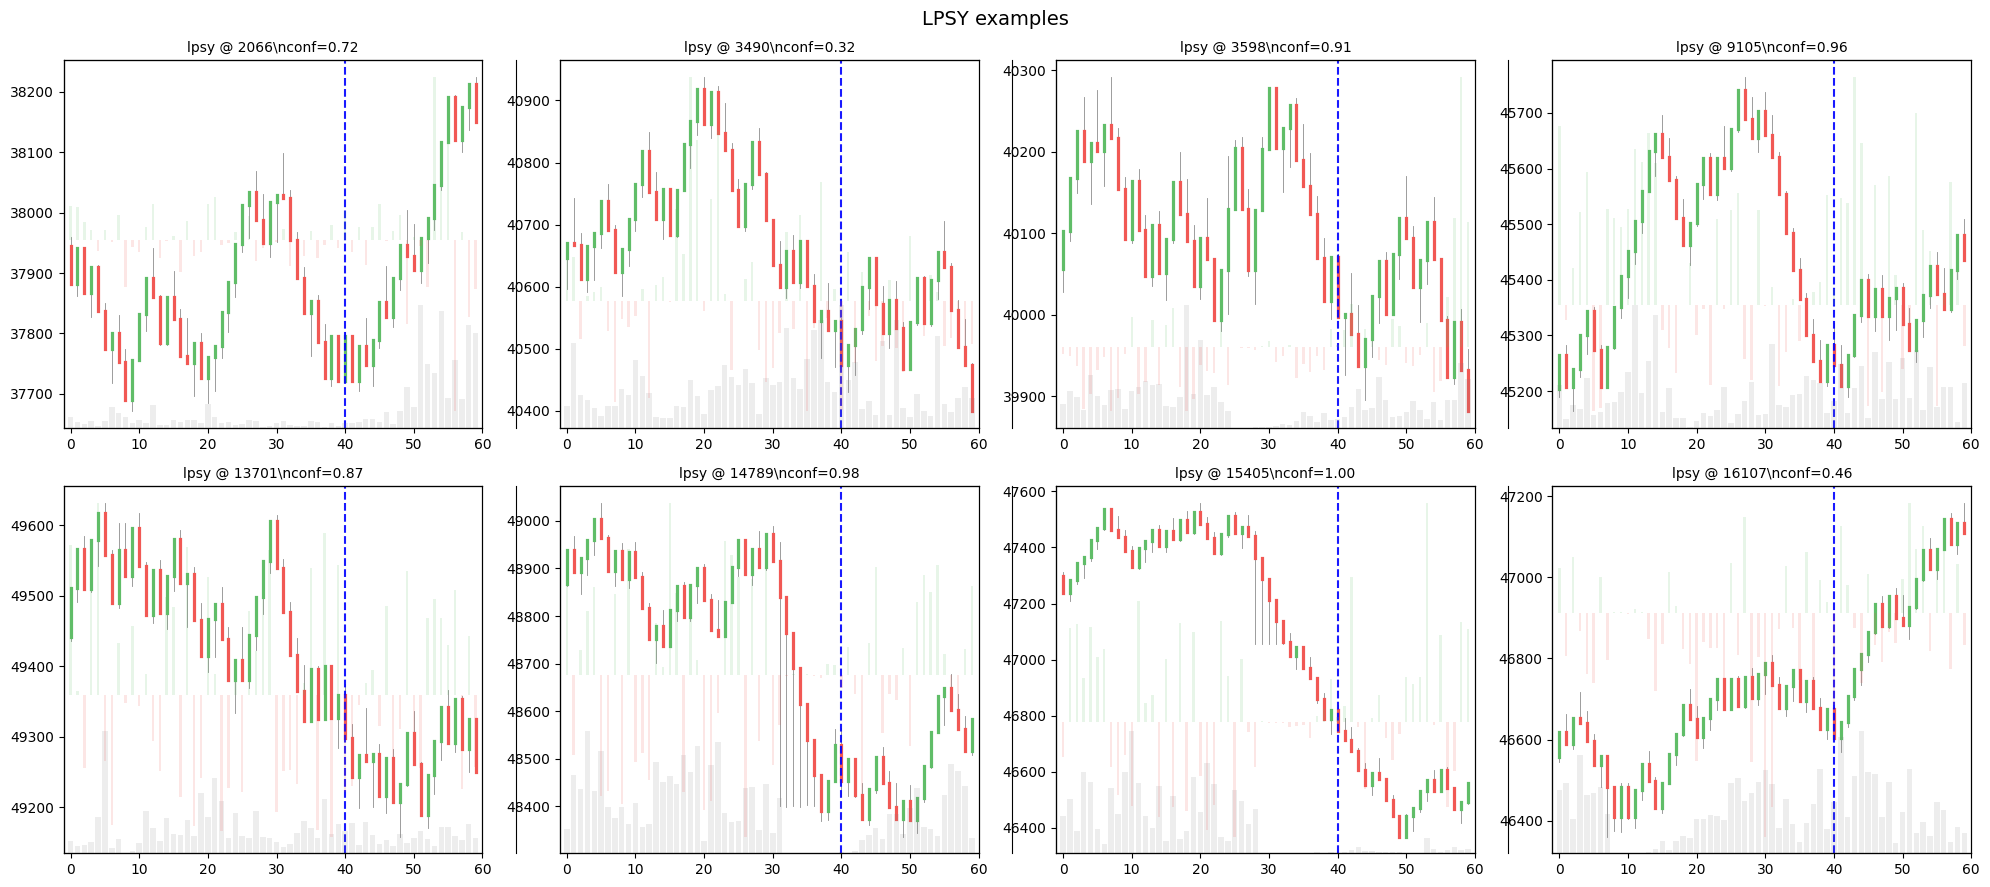

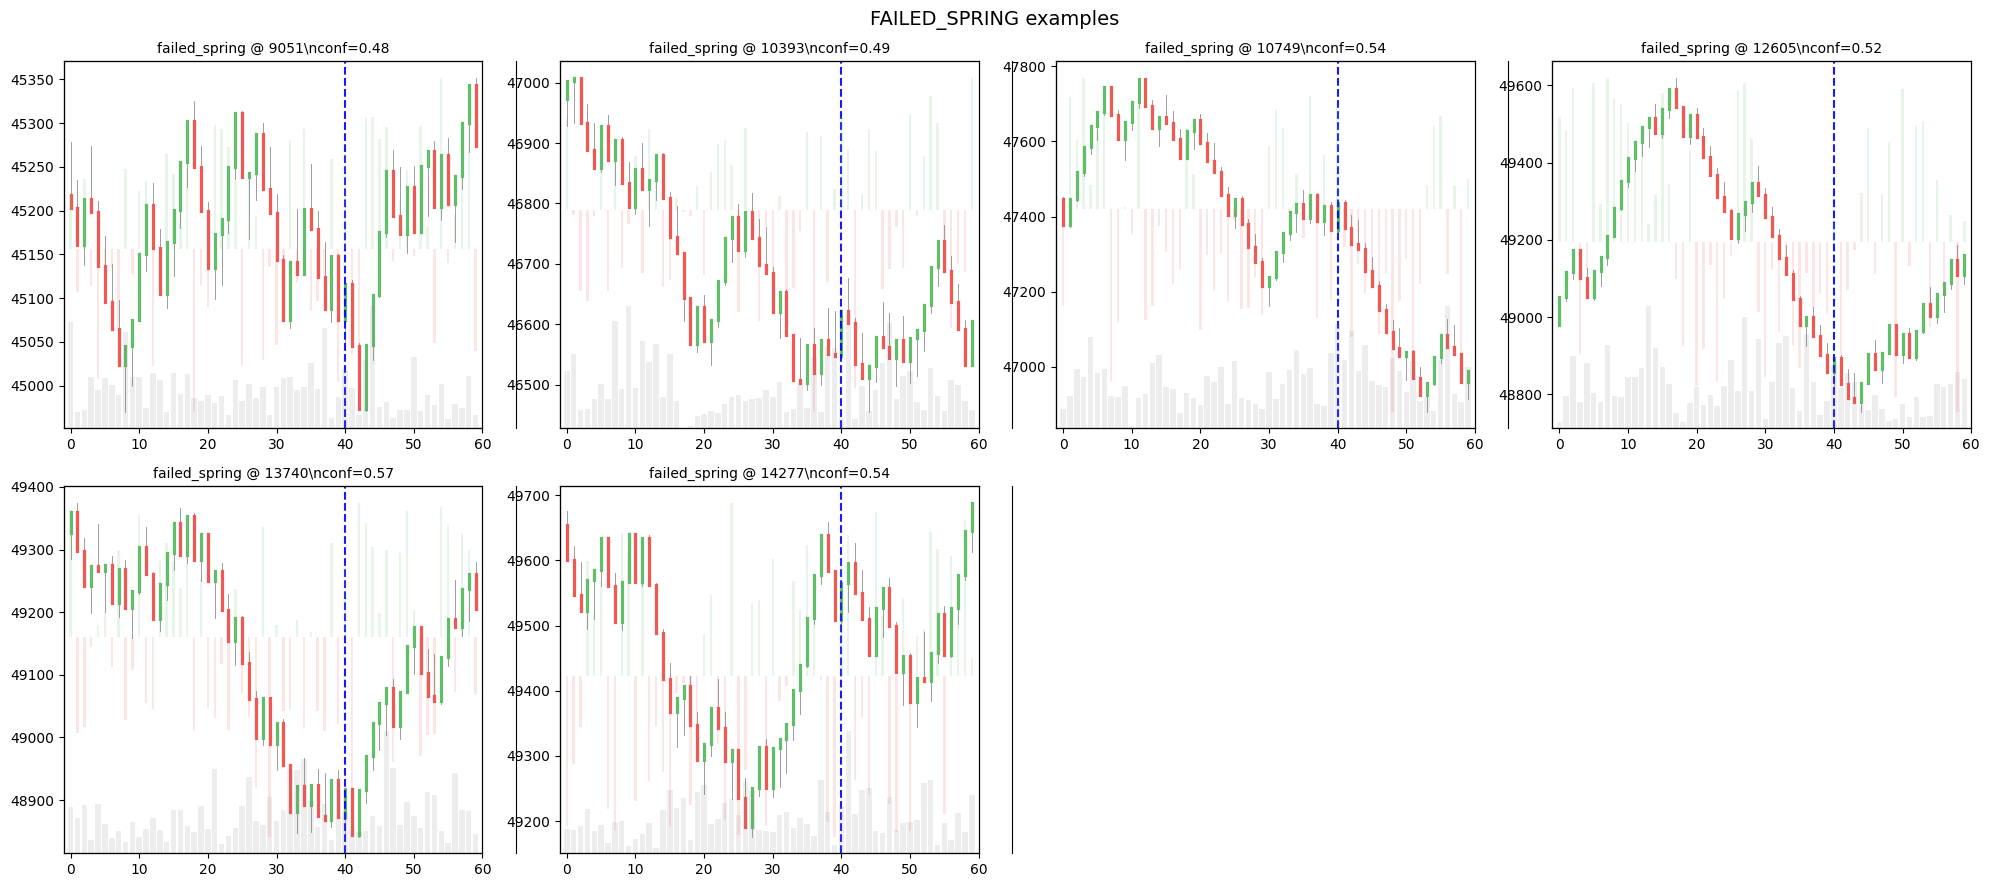

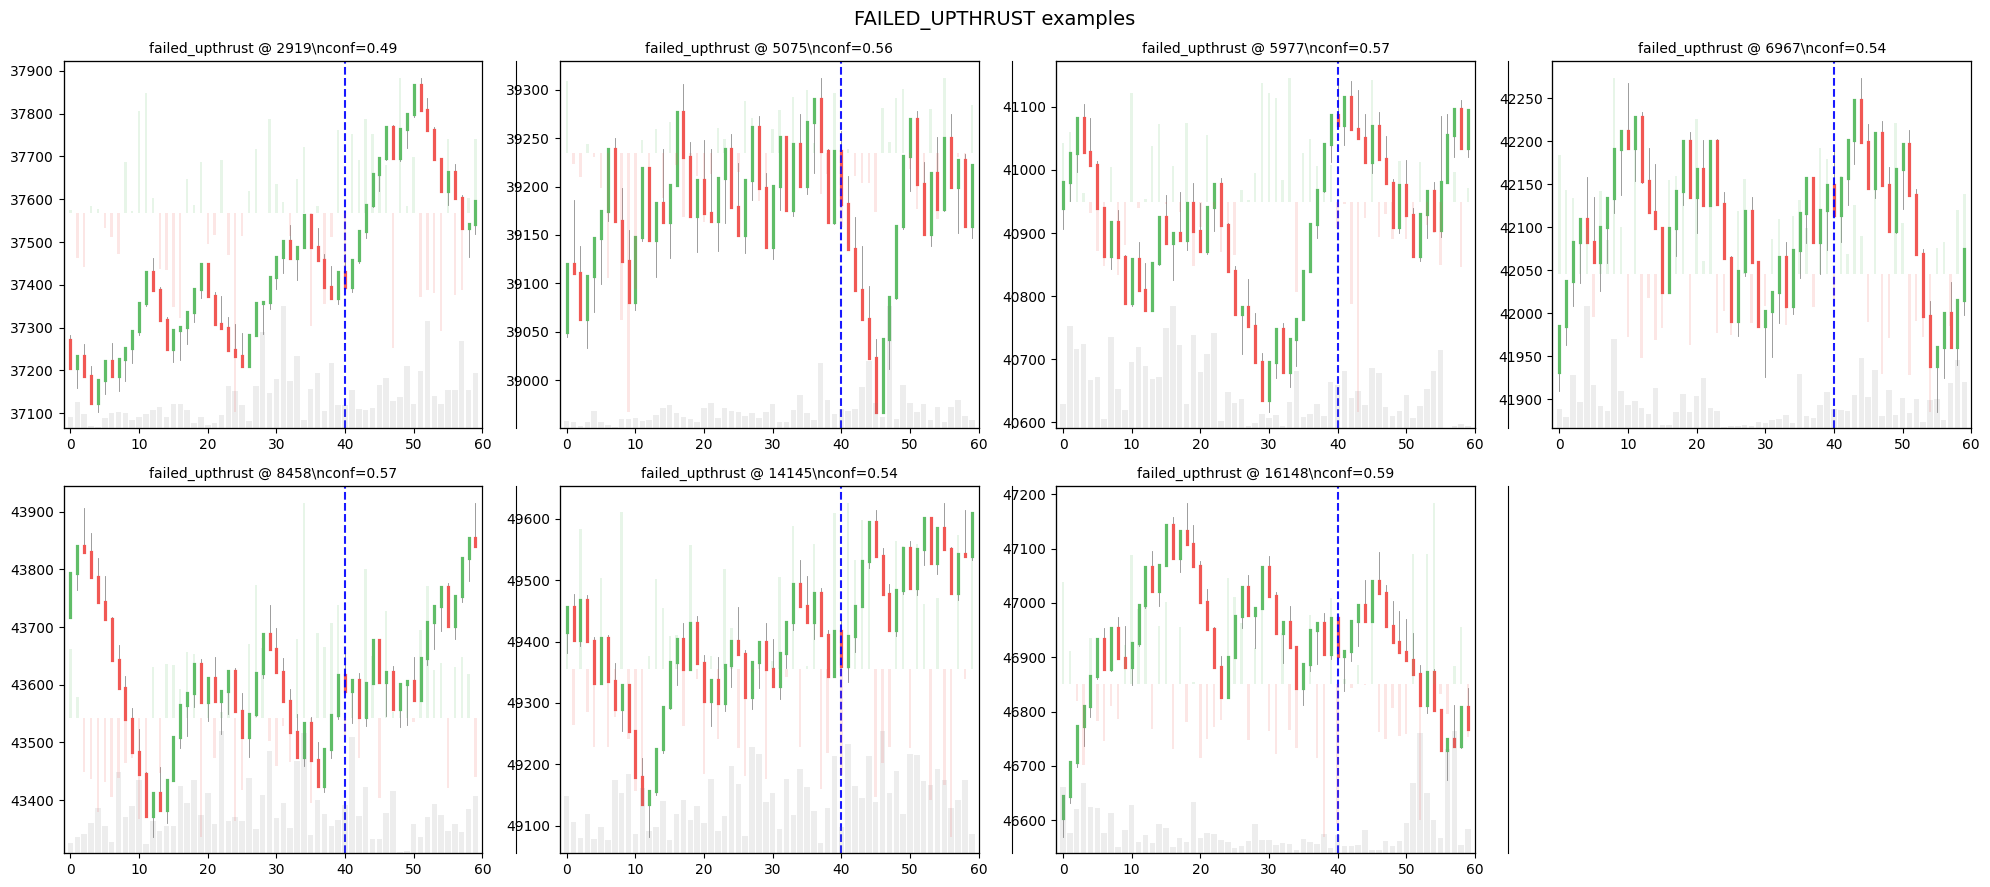

In [9]:
#Run any of these manually as needed:
plot_event_examples('spring')
plot_event_examples('upthrust')
plot_event_examples('sos')
plot_event_examples('sow')
plot_event_examples('lps')
plot_event_examples('lpsy')
plot_event_examples('failed_spring')
plot_event_examples('failed_upthrust')

In [10]:
close = bars["close"].values.astype(np.float64)
horizons = [5, 10, 20, 50]
fwd_returns = {}

for h in horizons:
    fr = np.full(len(close), np.nan)
    fr[:-h] = (close[h:] - close[:-h]) / np.maximum(close[:-h], 1e-9) * 100.0
    fwd_returns[h] = fr

print("=== Forward returns by event ===")
print(f"{'Event':20s} {'N':>6s} {'Conf>=.75':>10s} " + " ".join([f"{h:>8d}b" for h in horizons]))
print("-" * 90)

for j, name in enumerate(EVENT_NAMES):
    mask = EVENT_ACTIVE[:, j]
    n = mask.sum()
    hi = (EVENT_ACTIVE[:, j] & (event_conf[:, j] >= 0.75)).sum()
    vals = []
    for h in horizons:
        ret = fwd_returns[h][mask]
        ret = ret[~np.isnan(ret)]
        vals.append(np.mean(ret) if len(ret) > 0 else np.nan)
    vals_str = " ".join([f"{v:+8.3f}" if np.isfinite(v) else "    N/A " for v in vals])
    print(f"{name:20s} {n:6d} {hi:10d} {vals_str}")

print("\n=== Directional accuracy (10-bar horizon) ===")
for j, name in enumerate(EVENT_NAMES):
    mask = EVENT_ACTIVE[:, j]
    ret = fwd_returns[10][mask]
    ret = ret[~np.isnan(ret)]
    if len(ret) == 0:
        print(f"  {name:20s}: no valid forward bars")
        continue
    expected = EVENT_EXPECTED_SIGN[name]
    acc = (ret > 0).mean() * 100 if expected > 0 else (ret < 0).mean() * 100
    print(f"  {name:20s}: {acc:5.1f}%   n={len(ret):5d}")

print("\n=== High-confidence directional accuracy (10-bar horizon, conf>=0.75) ===")
for j, name in enumerate(EVENT_NAMES):
    mask = EVENT_ACTIVE[:, j] & (event_conf[:, j] >= 0.75)
    ret = fwd_returns[10][mask]
    ret = ret[~np.isnan(ret)]
    if len(ret) < 5:
        print(f"  {name:20s}: too few hi-conf events ({len(ret)})")
        continue
    expected = EVENT_EXPECTED_SIGN[name]
    acc = (ret > 0).mean() * 100 if expected > 0 else (ret < 0).mean() * 100
    print(f"  {name:20s}: {acc:5.1f}%   n={len(ret):5d}")


=== Forward returns by event ===
Event                     N  Conf>=.75        5b       10b       20b       50b
------------------------------------------------------------------------------------------
selling_climax          236         51   +0.009   +0.037   +0.078   +0.135
automatic_rally         236        104   +0.041   +0.060   +0.066   +0.083
st_support               87         22   -0.022   -0.019   -0.027   -0.044
spring                   30         10   +0.040   +0.084   +0.026   +0.037
sos                      12         10   -0.113   -0.247   -0.121   -0.120
lps                       5          5   -0.130   -0.142   +0.039   +0.041
buying_climax           241         55   -0.018   -0.013   -0.025   -0.088
automatic_reaction      241        119   -0.008   +0.018   +0.027   +0.003
st_resistance            93         26   -0.000   -0.001   -0.050   -0.065
upthrust                 33         15   -0.062   -0.118   -0.058   -0.018
sow                      15          6   -0.034

In [ ]:
import torch
import glob

ckpt_path = f"{PRETRAIN_DIR}/pretrained_best.pt"
if not Path(ckpt_path).exists():
    ckpts = sorted(glob.glob(f"{PRETRAIN_DIR}/pretrained_*.pt"))
    ckpt_path = ckpts[-1] if ckpts else None

if ckpt_path:
    print(f"Loading checkpoint: {ckpt_path}")
    ckpt = torch.load(ckpt_path, map_location="cpu")
    config = ckpt["config"]
    print(
        f"Config: d_model={config.d_model}, "
        f"n_layers={config.n_layers}, "
        f"d_ff={config.d_ff}, "
        f"seq_len={config.seq_len}"
    )
    print(
        f"Best epoch: {ckpt.get('epoch', '?')}, "
        f"val_loss: {ckpt.get('val_loss', '?'):.4f}, "
        f"phase_acc: {ckpt.get('phase_acc', '?'):.4f}"
    )
else:
    print("No pretrained checkpoint found")
    ckpt = None


In [ ]:
if ckpt is not None:
    from wyckoff_rl.transformer.train import WyckoffSequenceDataset
    from wyckoff_rl.transformer.encoder import WyckoffTransformerEncoder
    from wyckoff_rl.transformer.heads import PhaseHead, EventHead
    from sklearn.metrics import (
        confusion_matrix,
        classification_report,
        precision_recall_curve,
        average_precision_score,
        ConfusionMatrixDisplay,
    )

    encoder = WyckoffTransformerEncoder(config)
    phase_head = PhaseHead(config)
    event_head = EventHead(config)

    encoder.load_state_dict(ckpt["encoder"])
    phase_head.load_state_dict(ckpt["phase_head"])
    event_head.load_state_dict(ckpt["event_head"])

    encoder.eval()
    phase_head.eval()
    event_head.eval()

    full_ds = WyckoffSequenceDataset(NPZ_PATH, LABEL_PATH, config, augment=False, end_idx=0)
    full_ds.feat_mean = ckpt["feat_mean"]
    full_ds.feat_std = ckpt["feat_std"]

    if TRAIN_END_BAR > 0:
        val_start_sample = max(0, TRAIN_END_BAR - full_ds.seq_len)
        eval_indices = list(range(val_start_sample, len(full_ds)))
    else:
        eval_indices = list(range(len(full_ds)))

    eval_subset = torch.utils.data.Subset(full_ds, eval_indices)
    eval_loader = torch.utils.data.DataLoader(eval_subset, batch_size=256, shuffle=False)

    all_regime_pred = []
    all_regime_true = []
    all_event_logits = []
    all_event_true = []
    all_event_conf = []

    with torch.no_grad():
        for batch in eval_loader:
            feats = batch["features"]
            latent = encoder(feats)
            last_latent = latent[:, -1, :]
            regime_logits = phase_head(last_latent)
            event_logits = event_head(last_latent)

            all_regime_pred.append(regime_logits.argmax(dim=1).cpu().numpy())
            all_regime_true.append(batch["phase"].cpu().numpy())
            all_event_logits.append(event_logits.cpu().numpy())
            all_event_true.append(batch["events"].cpu().numpy())
            all_event_conf.append(batch["event_weight"].cpu().numpy())

    regime_pred = np.concatenate(all_regime_pred)
    regime_true = np.concatenate(all_regime_true)
    event_logits_all = np.concatenate(all_event_logits)
    event_true_all = np.concatenate(all_event_true)
    event_conf_all = np.concatenate(all_event_conf)
    event_probs = 1.0 / (1.0 + np.exp(-event_logits_all))

    valid_phase = regime_true != PHASE_IGNORE_INDEX
    print(f"Eval samples total: {len(regime_pred)}")
    print(f"Eval phase-valid: {valid_phase.sum()}")
    print(f"Phase accuracy (valid only): {(regime_pred[valid_phase] == regime_true[valid_phase]).mean() * 100:.1f}%")
else:
    print("Skipping -- no checkpoint")


In [ ]:
if ckpt is not None:
    valid_phase = regime_true != PHASE_IGNORE_INDEX
    y_true = regime_true[valid_phase]
    y_pred = regime_pred[valid_phase]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(REGIME_NAMES))))
    disp = ConfusionMatrixDisplay(cm, display_labels=REGIME_NAMES)
    disp.plot(ax=axes[0], cmap="Blues", values_format="d")
    axes[0].set_title("Phase Confusion Matrix (counts)")

    cm_norm = confusion_matrix(y_true, y_pred, labels=list(range(len(REGIME_NAMES))), normalize="true")
    disp_norm = ConfusionMatrixDisplay(cm_norm, display_labels=REGIME_NAMES)
    disp_norm.plot(ax=axes[1], cmap="Blues", values_format=".2f")
    axes[1].set_title("Phase Confusion Matrix (normalized)")

    plt.tight_layout()
    plt.show()

    print("\n=== Phase Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=REGIME_NAMES, digits=3, zero_division=0))
else:
    print("Skipping -- no checkpoint")


In [ ]:
if ckpt is not None:
    from sklearn.metrics import precision_recall_curve, average_precision_score

    n_rows, n_cols = 4, 4
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 14))
    axes = axes.flatten()

    print("=== Event PR-AUC ===")
    for j, name in enumerate(EVENT_NAMES):
        ax = axes[j]
        y_true = (event_true_all[:, j] > 0.5).astype(int)
        y_score = event_probs[:, j]

        pos = y_true.sum()
        neg = len(y_true) - pos
        baseline = pos / max(len(y_true), 1)

        if pos < 5:
            ax.text(0.5, 0.5, f"{name}\nToo few positives ({pos})", transform=ax.transAxes, ha="center", va="center")
            ax.set_axis_off()
            print(f"  {name:20s}: SKIP (only {pos} positives)")
            continue

        ap = average_precision_score(y_true, y_score)
        precision, recall, _ = precision_recall_curve(y_true, y_score)

        ax.plot(recall, precision, lw=2, color="blue", label=f"AP={ap:.3f}")
        ax.axhline(baseline, color="red", ls="--", alpha=0.5, label=f"Base={baseline:.3f}")
        ax.set_xlim(0, 1.05)
        ax.set_ylim(0, 1.05)
        ax.set_title(name, fontsize=10)
        ax.legend(fontsize=8)

        lift = ap / baseline if baseline > 0 else np.nan
        print(f"  {name:20s}: AP={ap:.4f}, baseline={baseline:.4f}, lift={lift:5.2f}x, pos={pos}, neg={neg}")

    for k in range(len(EVENT_NAMES), len(axes)):
        axes[k].set_visible(False)

    plt.suptitle("Event Detection Precision-Recall Curves", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Skipping -- no checkpoint")


In [ ]:
print("=" * 80)
print("LABEL AUDIT SUMMARY")
print("=" * 80)

phase_counts = np.bincount(regime[VALID_PHASE_MASK], minlength=len(REGIME_NAMES))
phase_majority_pct = phase_counts.max() / max(VALID_PHASE_MASK.sum(), 1) * 100
ignored_pct = (~VALID_PHASE_MASK).sum() / len(regime) * 100

print("\n1. PHASE QUALITY")
print(f"   Valid phase bars: {VALID_PHASE_MASK.sum()} / {len(regime)} ({100 - ignored_pct:.1f}%)")
print(f"   Ignored bars: {(~VALID_PHASE_MASK).sum()} ({ignored_pct:.1f}%)")
print(f"   Majority valid phase: {REGIME_NAMES[phase_counts.argmax()]} ({phase_majority_pct:.1f}%)")
if phase_majority_pct > 70:
    print("   WARNING: phase imbalance is high")
else:
    print("   OK: phase balance is usable")

print("\n2. EVENT SPARSITY")
for j, name in enumerate(EVENT_NAMES):
    pct = EVENT_ACTIVE[:, j].mean() * 100
    if pct < 0.2:
        status = "VERY SPARSE"
    elif pct < 0.75:
        status = "SPARSE"
    elif pct > 8.0:
        status = "TOO FREQUENT"
    else:
        status = "OK"
    print(f"   {name:20s}: {pct:5.2f}%  -> {status}")

print("\n3. CONTRADICTIONS")
for a, b in [
    ("spring", "upthrust"),
    ("sos", "sow"),
    ("lps", "lpsy"),
    ("failed_spring", "failed_upthrust"),
]:
    both = np.logical_and(
        EVENT_ACTIVE[:, EVENT_NAMES.index(a)],
        EVENT_ACTIVE[:, EVENT_NAMES.index(b)],
    ).sum()
    print(f"   {a:20s} & {b:20s}: {both:5d}")

print("\n4. DIRECTIONAL VALIDITY (10-bar, all confidence levels)")
close = bars["close"].values.astype(np.float64)
fr10 = np.full(len(close), np.nan)
fr10[:-10] = (close[10:] - close[:-10]) / np.maximum(close[:-10], 1e-9) * 100.0

for j, name in enumerate(EVENT_NAMES):
    mask = EVENT_ACTIVE[:, j]
    ret = fr10[mask]
    ret = ret[~np.isnan(ret)]
    if len(ret) < 5:
        print(f"   {name:20s}: too few events")
        continue
    expected = EVENT_EXPECTED_SIGN[name]
    acc = (ret > 0).mean() * 100 if expected > 0 else (ret < 0).mean() * 100
    print(f"   {name:20s}: {acc:5.1f}% directionally correct (n={len(ret)})")

print("\n5. WHAT TO MANUALLY VERIFY")
print("   - Springs occur after a mature accumulation range, not random support pokes")
print("   - Upthrusts occur after a mature distribution range, not random resistance pokes")
print("   - SOS/SOW are true range exits, not one-bar overshoots")
print("   - LPS/LPSY are low-effort pullbacks after breakout")
print("   - Failed spring / failed upthrust labels are genuinely opposite-outcome events")
print("   - phase_weight is zero on ignored bars and positive on valid phase bars")
print("   - event_weight is zero on negatives and positive on positive event labels")

print("\n6. GO / NO-GO RULE")
print("   GO if:")
print("     - contradiction overlaps are near zero")
print("     - spring / upthrust / SOS / SOW directional hit-rates are clearly > 50%")
print("     - event frequencies are sparse but not absurdly sparse")
print("     - PR-AUC beats baseline by a meaningful margin")
